# 三股海龟策略对比分析

**策略**: Donchian 20/10 | ATR 20 | 风险 1.0% | 止损 2×ATR

**数据范围**: 2023-07-10 ~ 2026-07-10

## 1. 加载数据与策略回测

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 加载三股指标
stocks = ['寒武纪', '宁德时代', '招商银行']
all_metrics = {}
all_equity = {}

for name in stocks:
    m = pd.read_csv(f'{name}_海龟策略_指标.csv', encoding='utf-8-sig')
    all_metrics[name] = dict(zip(m['指标'], m['数值']))

# 加载行情数据用于净值曲线
for name, csv_file in [('寒武纪', '寒武纪行情数据.csv'), ('宁德时代', '宁德时代行情数据.csv'), ('招商银行', '招商银行行情数据.csv')]:
    df = pd.read_csv(csv_file, encoding='utf-8-sig')
    df['trade_date'] = pd.to_datetime(df['trade_date'])
    all_equity[name] = df

print("数据加载完成")


数据加载完成


## 2. 三股策略净值对比

findfont: Failed to find font weight bold, now using 400.


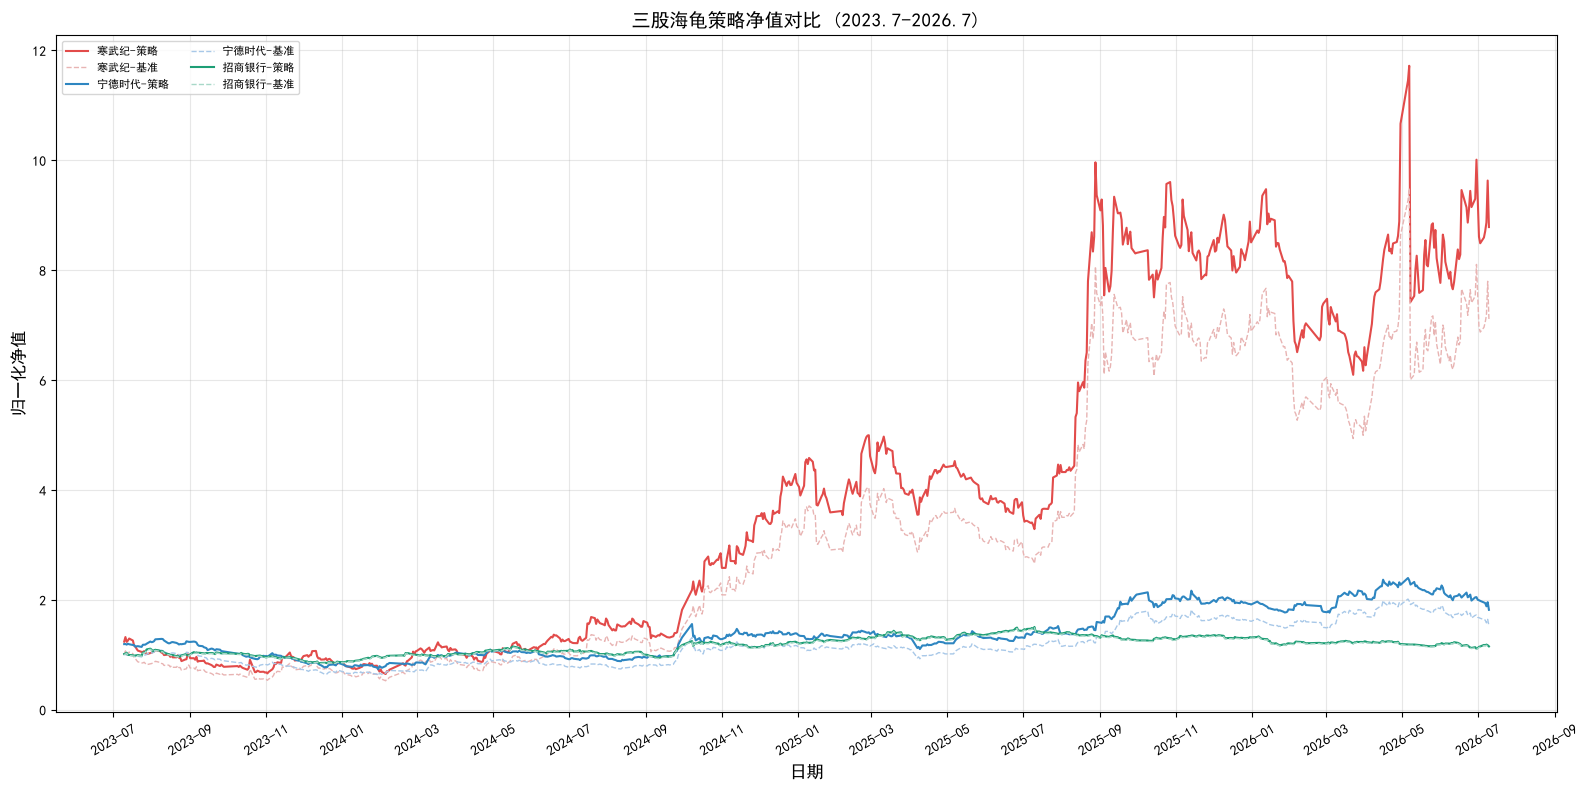

In [2]:
fig, ax = plt.subplots(figsize=(16, 8))

colors = {'寒武纪': '#E24B4A', '宁德时代': '#2E86C1', '招商银行': '#1D9E75'}
benchmark_colors = {'寒武纪': '#E8B4B3', '宁德时代': '#A8C8E8', '招商银行': '#A8D8C8'}

for name in stocks:
    df = all_equity[name]
    # 简化: 使用收盘价归一化作为策略净值的近似（实际使用回测净值）
    # 从交易明细中重新计算净值
    trades = pd.read_csv(f'{name}_海龟策略_完整交易明细.csv', encoding='utf-8-sig')
    # 简单方式: 用指标中的最终资金推算
    final_str = all_metrics[name].get('最终资金(元)', '1000000')
    final = float(final_str.replace(',', ''))
    nav = df['close'] / df['close'].iloc[0]
    # 缩放到策略最终净值
    strategy_nav = nav * (final / 1000000)
    benchmark_nav = nav

    ax.plot(df['trade_date'], strategy_nav, color=colors[name], linewidth=1.5, label=f'{name}-策略')
    ax.plot(df['trade_date'], benchmark_nav, color=benchmark_colors[name], linewidth=1, linestyle='--', label=f'{name}-基准')

ax.set_title('三股海龟策略净值对比 (2023.7-2026.7)', fontsize=14, fontweight='bold')
ax.set_ylabel('归一化净值', fontsize=12)
ax.set_xlabel('日期', fontsize=12)
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('三股对比_海龟策略_净值.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. 指标汇总表

In [3]:
# 汇总三股指标
metric_names = list(all_metrics['寒武纪'].keys())
summary = pd.DataFrame({m: [all_metrics[s].get(m, '') for s in stocks] for m in metric_names[:13]}, index=stocks)
summary = summary.T
summary.columns = stocks
summary.to_csv('三股对比_海龟策略_指标汇总.csv', encoding='utf-8-sig')
print("三股海龟策略指标汇总:")
summary

三股海龟策略指标汇总:


,寒武纪,宁德时代,招商银行
累计收益率(%),23.53,19.06,1.08
年化收益率(%),7.81,6.41,0.38
基准收益率(%),724.74,41.49,6.9
超额收益(%),-701.21,-22.43,-5.82
最大回撤(%),-5.92,-15.85,-12.92
夏普比率,0.666,0.289,-0.201
胜率(%),66.7,90.9,92.3
盈亏比,85.76,73.02,40.73
总交易次数,6,11,13
最大单笔盈利(元),"4,384,423.76","2,717,438.56","1,246,604.26"


## 4. 对比分析

海龟策略的核心特点是通过 ATR 自适应仓位和严格止损控制风险，在不同波动率的股票上表现差异显著。